# UTS - KLASIFIKASI BERITA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gensim matplotlib numpy


In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.2 MB/s eta 0:00:00


# **Load Dataset**

In [3]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/PPW (1)/UTS/Berita (1).csv'
df = pd.read_csv(file_path)

# Tampilkan 5 baris pertama
df.head()


,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...


In [4]:
import pandas as pd

# Load data asli
file_path = '/content/drive/MyDrive/PPW (1)/UTS/Berita (1).csv'
df = pd.read_csv(file_path)

# Ambil hanya kolom 'berita' dan 'berita', lalu hapus baris kosong
isi_df = df[['berita', 'kategori']].dropna().reset_index(drop=True)

# Simpan hasilnya ke CSV baru
isi_df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/Berita_baru1.csv', index=False)
print("✅ Data dengan dua kolom (isi_berita & kategori_berita) berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df.head(10)


✅ Data dengan dua kolom (isi_berita & kategori_berita) berhasil disimpan ke CSV!



,berita,kategori
0,Menteri Koordinator (Menko) Bidang Perekonomia...,Ekonomi
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",Ekonomi
2,Wacana Presiden Prabowo Subianto akan membentu...,Ekonomi
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,Ekonomi
4,Pemerintah akan segera membentuk Satuan Tugas ...,Ekonomi
5,Menko Bidang Infrastruktur dan Pembangunan Kew...,Ekonomi
6,Kepala Badan Gizi Nasional Dadan Hindayana men...,Ekonomi
7,Menteri Koordinator Bidang Pangan Zulkifli Has...,Ekonomi
8,Uji coba alias commissioning pembangkit listri...,Ekonomi
9,Anak crazy rich pengusaha sawit Kalimantan Sam...,Ekonomi


In [5]:
# Jumlah data awal sebelum drop NaN
total_awal = len(df)
print("Jumlah data awal:", total_awal)

# Jumlah data setelah drop NaN
total_setelah_drop = len(isi_df)
print("Jumlah data setelah drop NaN:", total_setelah_drop)


Jumlah data awal: 1500
Jumlah data setelah drop NaN: 1500


# **Preprocessing**

## **Cleanning**

In [6]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                  # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # hilangkan angka, tanda baca, simbol
    text = re.sub(r'\s+', ' ', text).strip() # hilangkan spasi berlebih
    return text

# Terapkan cleansing pada kolom 'isi_berita' saja
isi_df['cleaned'] = isi_df['berita'].apply(cleansing)

# Simpan hasil dengan kolom kategori_berita tetap ikut
isi_df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/Berita_cleaned1.csv', index=False)
print("✅ Data berhasil dibersihkan dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (kolom isi_berita, cleaned, kategori_berita)
isi_df[['berita', 'cleaned', 'kategori']].head(10)


✅ Data berhasil dibersihkan dan disimpan ke CSV!



,berita,cleaned,kategori
0,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...,Ekonomi
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...,Ekonomi
2,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...,Ekonomi
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...,Ekonomi
4,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...,Ekonomi
5,Menko Bidang Infrastruktur dan Pembangunan Kew...,menko bidang infrastruktur dan pembangunan kew...,Ekonomi
6,Kepala Badan Gizi Nasional Dadan Hindayana men...,kepala badan gizi nasional dadan hindayana men...,Ekonomi
7,Menteri Koordinator Bidang Pangan Zulkifli Has...,menteri koordinator bidang pangan zulkifli has...,Ekonomi
8,Uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...,Ekonomi
9,Anak crazy rich pengusaha sawit Kalimantan Sam...,anak crazy rich pengusaha sawit kalimantan sam...,Ekonomi


## **Stopword**

In [7]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat stopword remover
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

# Terapkan stopword removal pada kolom 'cleaned' saja
isi_df['no_stopwords'] = isi_df['cleaned'].apply(stopword.remove)

# Simpan hasil ke CSV (kategori tetap ikut)
isi_df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/Berita_no_stopwords.csv', index=False)
print("✅ Data berhasil dihapus stopwords-nya dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (termasuk kolom kategori)
isi_df[['cleaned', 'no_stopwords', 'kategori']].head(10)


✅ Data berhasil dihapus stopwords-nya dan disimpan ke CSV!



,cleaned,no_stopwords,kategori
0,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...,Ekonomi
1,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...,Ekonomi
2,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...,Ekonomi
3,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...,Ekonomi
4,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...,Ekonomi
5,menko bidang infrastruktur dan pembangunan kew...,menko bidang infrastruktur pembangunan kewilay...,Ekonomi
6,kepala badan gizi nasional dadan hindayana men...,kepala badan gizi nasional dadan hindayana men...,Ekonomi
7,menteri koordinator bidang pangan zulkifli has...,menteri koordinator bidang pangan zulkifli has...,Ekonomi
8,uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...,Ekonomi
9,anak crazy rich pengusaha sawit kalimantan sam...,anak crazy rich pengusaha sawit kalimantan sam...,Ekonomi


## **Stemming**

In [8]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords'
isi_df['stemmed'] = isi_df['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV (kategori tetap ikut)
isi_df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/berita_isi_stemmed1.csv', index=False)
print("✅ Data berhasil distemming dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (termasuk kolom kategori)
isi_df[['no_stopwords', 'stemmed', 'kategori']].head(10)


✅ Data berhasil distemming dan disimpan ke CSV!



,no_stopwords,stemmed,kategori
0,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...,Ekonomi
1,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...,Ekonomi
2,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...,Ekonomi
3,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...,Ekonomi
4,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...,Ekonomi
5,menko bidang infrastruktur pembangunan kewilay...,menko bidang infrastruktur bangun wilayah agus...,Ekonomi
6,kepala badan gizi nasional dadan hindayana men...,kepala badan gizi nasional dad hindayana sebut...,Ekonomi
7,menteri koordinator bidang pangan zulkifli has...,menteri koordinator bidang pangan zulkifli has...,Ekonomi
8,uji coba alias commissioning pembangkit listri...,uji coba alias commissioning bangkit listrik t...,Ekonomi
9,anak crazy rich pengusaha sawit kalimantan sam...,anak crazy rich usaha sawit kalimantan samsudi...,Ekonomi


## **Tokenisasi**

In [9]:
import pandas as pd

# Fungsi tokenisasi sederhana
def tokenize(text):
    return text.split()

# Terapkan tokenisasi pada kolom 'stemmed' saja
isi_df['tokens'] = isi_df['stemmed'].apply(tokenize)

# Simpan hasil ke CSV (kategori_berita tetap ikut)
isi_df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/berita_tokens1.csv', index=False)
print("✅ Data berhasil ditokenisasi dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (termasuk kategori)
isi_df[['stemmed', 'tokens', 'kategori']].head(10)


✅ Data berhasil ditokenisasi dan disimpan ke CSV!



,stemmed,tokens,kategori
0,menteri koordinator menko bidang ekonomi airla...,"[menteri, koordinator, menko, bidang, ekonomi,...",Ekonomi
1,rangka riah hari jadi pt surabaya industrial e...,"[rangka, riah, hari, jadi, pt, surabaya, indus...",Ekonomi
2,wacana presiden prabowo subianto bentuk bentuk...,"[wacana, presiden, prabowo, subianto, bentuk, ...",Ekonomi
3,bpjs ketenagakerjaan menteri agama kemenag ber...,"[bpjs, ketenagakerjaan, menteri, agama, kemena...",Ekonomi
4,perintah segera bentuk satu tugas putus hubung...,"[perintah, segera, bentuk, satu, tugas, putus,...",Ekonomi
5,menko bidang infrastruktur bangun wilayah agus...,"[menko, bidang, infrastruktur, bangun, wilayah...",Ekonomi
6,kepala badan gizi nasional dad hindayana sebut...,"[kepala, badan, gizi, nasional, dad, hindayana...",Ekonomi
7,menteri koordinator bidang pangan zulkifli has...,"[menteri, koordinator, bidang, pangan, zulkifl...",Ekonomi
8,uji coba alias commissioning bangkit listrik t...,"[uji, coba, alias, commissioning, bangkit, lis...",Ekonomi
9,anak crazy rich usaha sawit kalimantan samsudi...,"[anak, crazy, rich, usaha, sawit, kalimantan, ...",Ekonomi


In [20]:
# cek tipe data kolom isi berita hasil preprocessing yang sudah dibersihkan
type(isi_df['tokens'].iloc[0])

list

In [19]:
corpus = isi_df['tokens'].tolist()
print(corpus)

[['menteri', 'koordinator', 'menko', 'bidang', 'ekonomi', 'airlangga', 'hartarto', 'harap', 'naik', 'upah', 'minimum', 'provinsi', 'ump', 'besar', 'persen', 'tahun', 'tingkat', 'daya', 'beli', 'masyarakat', 'kelas', 'tengah', 'start', 'awal', 'tunjang', 'daya', 'beli', 'masyarakat', 'kelas', 'tengah', 'naik', 'upah', 'minimum', 'dongkrak', 'persen', 'kata', 'airlangga', 'sela', 'hadir', 'rapat', 'pimpin', 'nasional', 'rapimnas', 'kadin', 'jakarta', 'minggu', 'sampai', 'tengah', 'ketidakpastian', 'global', 'perintah', 'kuat', 'struktur', 'ekonomi', 'negeri', 'salah', 'satu', 'struktur', 'sebut', 'giat', 'belanja', 'kelompok', 'masyarakat', 'kelas', 'tengah', 'airlangga', 'tutur', 'kelompok', 'masyarakat', 'kelas', 'tengah', 'milik', 'peran', 'vital', 'dorong', 'komponen', 'konsumsi', 'konsumsi', 'lama', 'masih', 'jadi', 'topang', 'besar', 'tumbuh', 'ekonomi', 'nasional', 'perintah', 'segera', 'bentuk', 'satgas', 'phk', 'usai', 'tetap', 'ump', 'naik', 'persen', 'lihat', 'tengah', 'ketida

In [23]:
corpus_str = [' '.join(doc) for doc in corpus]  # ubah list token → string
X = vectorizer.fit_transform(corpus_str)
# Menampilkan jumlah dokumen dan fitur
print("Jumlah Dokumen :", X.shape[0])
print("Jumlah Fitur (Kosakata) :", X.shape[1])

Jumlah Dokumen : 1500
Jumlah Fitur (Kosakata) : 18437


In [25]:
from gensim import corpora

tokenized_text = isi_df['tokens'].tolist()
id2word = corpora.Dictionary(tokenized_text)
corpus_gensim = [id2word.doc2bow(text) for text in tokenized_text]


ValueError: x and y must have same first dimension, but have shapes (19,) and (0,)

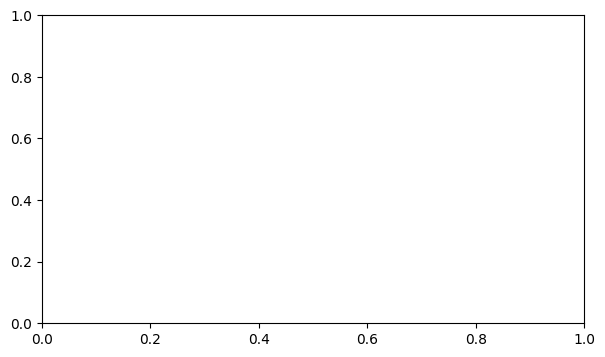

In [26]:
# --- Sinkronkan vocab sklearn ↔ gensim ---
import numpy as np
from gensim.models import CoherenceModel
from gensim import corpora

# 1) Ambil vocab dari CountVectorizer
vocab = vectorizer.get_feature_names_out().tolist()
vocab_set = set(vocab)

# 2) Pastikan tokenized_text = list of list token & difilter ke vocab sklearn
#    (pakai kolom tokens yang sudah kamu buat)
tokenized_text = [
    [w for w in doc if w in vocab_set]
    for doc in isi_df['tokens'].tolist()
]

# 3) Dictionary Gensim dibangun dari token yang sudah difilter (biar konsisten)
id2word = corpora.Dictionary(tokenized_text)
# --- Sesudah for-loop menghitung coherence_scores ---
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(list(topic_range), coherence_scores, marker='o')
plt.xlabel('Jumlah Topik (K)')
plt.ylabel('Coherence c_v')
plt.title('Coherence vs Jumlah Topik (sklearn LDA dinilai dengan Gensim)')
plt.grid(True)
plt.show()

# Ambil K terbaik
best_idx = int(np.argmax(coherence_scores))
best_k = list(topic_range)[best_idx]
best_score = coherence_scores[best_idx]
print(f"K terbaik = {best_k} dengan coherence = {best_score:.4f}")


#**Topic Modelling**

In [27]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.2 MB/s eta 0:00:00


In [29]:
!pip install gensim

In [46]:
import pandas as pd
import numpy as np
import re
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from IPython.display import display
import matplotlib.pyplot as plt
import pyLDAvis
import warnings
warnings.filterwarnings("ignore")
from gensim import corpora
from gensim.models import CoherenceModel
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from IPython.display import display
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from tqdm import tqdm


## **Load dataset**

In [31]:
df = pd.read_csv("/content/drive/MyDrive/PPW (1)/UTS/berita_tokens1.csv")
df

,berita,kategori,cleaned,no_stopwords,stemmed,tokens
0,Menteri Koordinator (Menko) Bidang Perekonomia...,Ekonomi,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...,"['menteri', 'koordinator', 'menko', 'bidang', ..."
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",Ekonomi,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...,"['rangka', 'riah', 'hari', 'jadi', 'pt', 'sura..."
2,Wacana Presiden Prabowo Subianto akan membentu...,Ekonomi,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...,"['wacana', 'presiden', 'prabowo', 'subianto', ..."
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,Ekonomi,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...,"['bpjs', 'ketenagakerjaan', 'menteri', 'agama'..."
4,Pemerintah akan segera membentuk Satuan Tugas ...,Ekonomi,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...,"['perintah', 'segera', 'bentuk', 'satu', 'tuga..."
...,...,...,...,...,...,...
1495,Anggota Dewan Keselamatan Transportasi Nasiona...,Internasional,anggota dewan keselamatan transportasi nasiona...,anggota dewan keselamatan transportasi nasiona...,anggota dewan selamat transportasi nasional nt...,"['anggota', 'dewan', 'selamat', 'transportasi'..."
1496,Israel telah membebaskan 110 tahanan Palestina...,Internasional,israel telah membebaskan tahanan palestina pad...,israel membebaskan tahanan palestina kamis wak...,israel bebas tahan palestina kamis waktu tempa...,"['israel', 'bebas', 'tahan', 'palestina', 'kam..."
1497,Hamas mengonfirmasi kematian kepala militernya...,Internasional,hamas mengonfirmasi kematian kepala militernya...,hamas mengonfirmasi kematian kepala militernya...,hamas konfirmasi mati kepala militer mohammed ...,"['hamas', 'konfirmasi', 'mati', 'kepala', 'mil..."
1498,Tim penyelam diduga menemukan satu dari dua bl...,Internasional,tim penyelam diduga menemukan satu dari dua bl...,tim penyelam diduga menemukan satu dua black b...,tim selam duga temu satu dua black box kotak h...,"['tim', 'selam', 'duga', 'temu', 'satu', 'dua'..."


## **Ubah tipe data dari str ke list**

In [32]:
# cek tipe data kolom isi berita hasil preprocessing
type(df['tokens'].iloc[0])

str

In [33]:
# mengubah tipe data kolom isi berita hasil preprocessing
# awalnya string diubah jadi list
df['tokens'] = df['tokens'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [34]:
# cek tipe data kolom isi berita hasil preprocessing
type(df['tokens'].iloc[0])

list

In [35]:
df

,berita,kategori,cleaned,no_stopwords,stemmed,tokens
0,Menteri Koordinator (Menko) Bidang Perekonomia...,Ekonomi,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...,"[menteri, koordinator, menko, bidang, ekonomi,..."
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",Ekonomi,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...,"[rangka, riah, hari, jadi, pt, surabaya, indus..."
2,Wacana Presiden Prabowo Subianto akan membentu...,Ekonomi,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...,"[wacana, presiden, prabowo, subianto, bentuk, ..."
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,Ekonomi,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...,"[bpjs, ketenagakerjaan, menteri, agama, kemena..."
4,Pemerintah akan segera membentuk Satuan Tugas ...,Ekonomi,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...,"[perintah, segera, bentuk, satu, tugas, putus,..."
...,...,...,...,...,...,...
1495,Anggota Dewan Keselamatan Transportasi Nasiona...,Internasional,anggota dewan keselamatan transportasi nasiona...,anggota dewan keselamatan transportasi nasiona...,anggota dewan selamat transportasi nasional nt...,"[anggota, dewan, selamat, transportasi, nasion..."
1496,Israel telah membebaskan 110 tahanan Palestina...,Internasional,israel telah membebaskan tahanan palestina pad...,israel membebaskan tahanan palestina kamis wak...,israel bebas tahan palestina kamis waktu tempa...,"[israel, bebas, tahan, palestina, kamis, waktu..."
1497,Hamas mengonfirmasi kematian kepala militernya...,Internasional,hamas mengonfirmasi kematian kepala militernya...,hamas mengonfirmasi kematian kepala militernya...,hamas konfirmasi mati kepala militer mohammed ...,"[hamas, konfirmasi, mati, kepala, militer, moh..."
1498,Tim penyelam diduga menemukan satu dari dua bl...,Internasional,tim penyelam diduga menemukan satu dari dua bl...,tim penyelam diduga menemukan satu dua black b...,tim selam duga temu satu dua black box kotak h...,"[tim, selam, duga, temu, satu, dua, black, box..."


# **Cleaning Ringan**

In [36]:
def pembersihan_teks(text):
    text = str(text)
    text = re.sub(r"[\[\]]", " ", text)    # hapus [ ]
    text = re.sub(r"[\'\"]", " ", text)    # hapus ' dan "
    text = re.sub(r",", " ", text)         # hapus koma
    text = re.sub(r"\s+", " ", text).strip()  # rapikan spasi
    return text

In [37]:
df['preprocessing'] = df['tokens'].apply(pembersihan_teks)

In [38]:
display(df[["tokens", "preprocessing"]].head(10))

,tokens,preprocessing
0,"[menteri, koordinator, menko, bidang, ekonomi,...",menteri koordinator menko bidang ekonomi airla...
1,"[rangka, riah, hari, jadi, pt, surabaya, indus...",rangka riah hari jadi pt surabaya industrial e...
2,"[wacana, presiden, prabowo, subianto, bentuk, ...",wacana presiden prabowo subianto bentuk bentuk...
3,"[bpjs, ketenagakerjaan, menteri, agama, kemena...",bpjs ketenagakerjaan menteri agama kemenag ber...
4,"[perintah, segera, bentuk, satu, tugas, putus,...",perintah segera bentuk satu tugas putus hubung...
5,"[menko, bidang, infrastruktur, bangun, wilayah...",menko bidang infrastruktur bangun wilayah agus...
6,"[kepala, badan, gizi, nasional, dad, hindayana...",kepala badan gizi nasional dad hindayana sebut...
7,"[menteri, koordinator, bidang, pangan, zulkifl...",menteri koordinator bidang pangan zulkifli has...
8,"[uji, coba, alias, commissioning, bangkit, lis...",uji coba alias commissioning bangkit listrik t...
9,"[anak, crazy, rich, usaha, sawit, kalimantan, ...",anak crazy rich usaha sawit kalimantan samsudi...


In [39]:
# kolom isi berita hasil preprocessing yang sudah dibersihkan ditambahkan ke kolom terakhir dataset
display(df.head())

,berita,kategori,cleaned,no_stopwords,stemmed,tokens,preprocessing
0,Menteri Koordinator (Menko) Bidang Perekonomia...,Ekonomi,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang perekonomian ...,menteri koordinator menko bidang ekonomi airla...,"[menteri, koordinator, menko, bidang, ekonomi,...",menteri koordinator menko bidang ekonomi airla...
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",Ekonomi,dalam rangka memeriahkan hari jadi ke pt surab...,rangka memeriahkan hari jadi pt surabaya indus...,rangka riah hari jadi pt surabaya industrial e...,"[rangka, riah, hari, jadi, pt, surabaya, indus...",rangka riah hari jadi pt surabaya industrial e...
2,Wacana Presiden Prabowo Subianto akan membentu...,Ekonomi,wacana presiden prabowo subianto akan membentu...,wacana presiden prabowo subianto membentuk mem...,wacana presiden prabowo subianto bentuk bentuk...,"[wacana, presiden, prabowo, subianto, bentuk, ...",wacana presiden prabowo subianto bentuk bentuk...
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,Ekonomi,bpjs ketenagakerjaan dan kementerian agama kem...,bpjs ketenagakerjaan kementerian agama kemenag...,bpjs ketenagakerjaan menteri agama kemenag ber...,"[bpjs, ketenagakerjaan, menteri, agama, kemena...",bpjs ketenagakerjaan menteri agama kemenag ber...
4,Pemerintah akan segera membentuk Satuan Tugas ...,Ekonomi,pemerintah akan segera membentuk satuan tugas ...,pemerintah segera membentuk satuan tugas pemut...,perintah segera bentuk satu tugas putus hubung...,"[perintah, segera, bentuk, satu, tugas, putus,...",perintah segera bentuk satu tugas putus hubung...


In [40]:
# cek tipe data kolom isi berita hasil preprocessing yang sudah dibersihkan
type(df['preprocessing'].iloc[0])

str

# **Corpus**

In [41]:
corpus = df['preprocessing'].tolist()
print(corpus)

['menteri koordinator menko bidang ekonomi airlangga hartarto harap naik upah minimum provinsi ump besar persen tahun tingkat daya beli masyarakat kelas tengah start awal tunjang daya beli masyarakat kelas tengah naik upah minimum dongkrak persen kata airlangga sela hadir rapat pimpin nasional rapimnas kadin jakarta minggu sampai tengah ketidakpastian global perintah kuat struktur ekonomi negeri salah satu struktur sebut giat belanja kelompok masyarakat kelas tengah airlangga tutur kelompok masyarakat kelas tengah milik peran vital dorong komponen konsumsi konsumsi lama masih jadi topang besar tumbuh ekonomi nasional perintah segera bentuk satgas phk usai tetap ump naik persen lihat tengah ketidakpastian global laku dalam struktur ekonomi indonesia jaga daya beli tingkat kelas tengah ujar sebut rata rata dapat masyarakat indonesia besar rp juta rp juta keluar bulan capai rp juta rp juta kata airlangga keluar warga banyak bawah rp juta bulan sekarang besar keluar bawah rp juta bulan nah

# **CountVectorizer**

In [42]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

# Menampilkan jumlah dokumen dan fitur
print("Jumlah Dokumen :", X.shape[0])
print("Jumlah Fitur (Kosakata) :", X.shape[1])

Jumlah Dokumen : 1500
Jumlah Fitur (Kosakata) : 18437


In [43]:
# Ambil kosakata dari vectorizer
vocab = vectorizer.get_feature_names_out()

# Tokenisasi agar cocok untuk Gensim
tokenized_text = [doc.split() for doc in corpus]

# Buat dictionary dan corpus versi Gensim
id2word = corpora.Dictionary(tokenized_text)
corpus_gensim = [id2word.doc2bow(text) for text in tokenized_text]

## **Jumlah topik terbaik (optimal number of topics)**

In [48]:
import numpy as np
from tqdm import tqdm
from gensim.models import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# === konfigurasi dasar ===
topic_range = range(10, 105, 5)
coherence_scores = []
best_score = -np.inf
best_k = None

print("🚀 Mulai menghitung coherence score untuk berbagai jumlah topik...\n")

# loop utama dengan progress bar
for k in tqdm(topic_range, desc="Evaluasi LDA", ncols=90):
    lda = LatentDirichletAllocation(
        n_components=k,
        max_iter=20,
        learning_method='batch',
        random_state=42
    ).fit(X)

    # ambil top 10 kata per topik
    topic_word = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
    topics = [
        [vocab[i] for i in topic.argsort()[:-11:-1]]
        for topic in topic_word
    ]

    # hitung coherence
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized_text,
        dictionary=id2word,
        coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append(score)

    delta = score - coherence_scores[-2] if len(coherence_scores) > 1 else 0.0
    print(f"Jumlah topik {k:3d} | Coherence = {score:.4f} | Δ = {delta:+.4f}")

    # update hasil terbaik
    if score > best_score:
        best_score = score
        best_k = k

print("\n✅ Perhitungan selesai!")
print(f"🏆 Jumlah topik terbaik: {best_k} (Coherence = {best_score:.4f})")


🚀 Mulai menghitung coherence score untuk berbagai jumlah topik...



Evaluasi LDA:   5%|██                                      | 1/19 [00:30<09:14, 30.79s/it]

Jumlah topik  10 | Coherence = 0.5759 | Δ = +0.0000


Evaluasi LDA:  11%|████▏                                   | 2/19 [00:59<08:25, 29.73s/it]

Jumlah topik  15 | Coherence = 0.6093 | Δ = +0.0334


...

Jumlah topik  90 | Coherence = 0.5589 | Δ = -0.0027


Evaluasi LDA:  95%|████████████████████████████████████  | 18/19 [22:12<01:46, 106.69s/it]

Jumlah topik  95 | Coherence = 0.5606 | Δ = +0.0017


Evaluasi LDA: 100%|███████████████████████████████████████| 19/19 [24:14<00:00, 76.55s/it]

Jumlah topik 100 | Coherence = 0.5492 | Δ = -0.0114

✅ Perhitungan selesai!
🏆 Jumlah topik terbaik: 20 (Coherence = 0.6136)


## **Visualisasi Coherence Score**

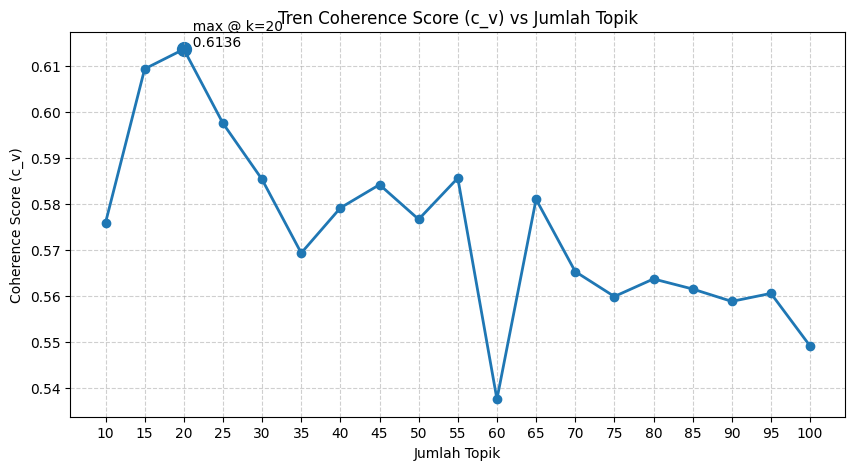

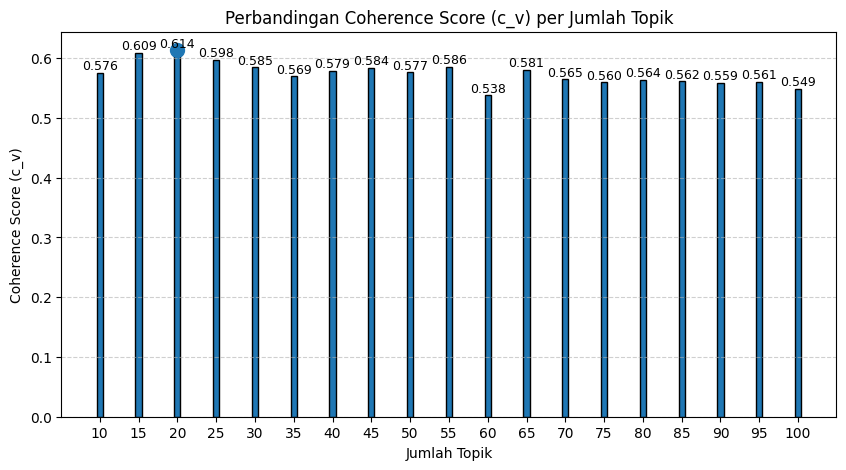

🏆 Terbaik: k=20 dengan coherence=0.6136


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# --- Siapkan data dari hasil sebelumnya ---
topics_k = list(topic_range)  # e.g., [10, 15, ..., 100]
scores = list(coherence_scores)

if len(topics_k) != len(scores):
    raise ValueError("Panjang topic_range dan coherence_scores harus sama.")

# --- Cari titik terbaik ---
best_idx = int(np.argmax(scores))
best_k = topics_k[best_idx]
best_score = scores[best_idx]

# =============== Chart 1: Line (tren coherence) ===============
plt.figure(figsize=(10, 5))
plt.plot(topics_k, scores, marker='o', linewidth=2)
plt.title("Tren Coherence Score (c_v) vs Jumlah Topik")
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score (c_v)")
plt.xticks(topics_k, rotation=0)

# Anotasi titik maksimum
plt.scatter([best_k], [best_score], s=100)
plt.text(best_k, best_score, f"  max @ k={best_k}\n  {best_score:.4f}",
         va='bottom', ha='left')
plt.grid(True, linestyle='--', alpha=0.6)

# Simpan (opsional)
# plt.savefig("/content/drive/MyDrive/PPW/coherence_line.png", dpi=150, bbox_inches="tight")
plt.show()

# =============== Chart 2: Bar (perbandingan per k) ===============
plt.figure(figsize=(10, 5))
plt.bar(topics_k, scores, edgecolor='black')
plt.title("Perbandingan Coherence Score (c_v) per Jumlah Topik")
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score (c_v)")
plt.xticks(topics_k, rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Label nilai di atas bar
for x, y in zip(topics_k, scores):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

# Highlight bar maksimum (opsional, tetap tanpa warna khusus)
# Bisa dengan menambah marker di atasnya:
plt.plot([best_k], [best_score], marker='o', markersize=10)

# Simpan (opsional)
# plt.savefig("/content/drive/MyDrive/PPW/coherence_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"🏆 Terbaik: k={best_k} dengan coherence={best_score:.4f}")


## **model LDA**

In [50]:
jumlah_topik = 20

In [51]:
lda_model = LatentDirichletAllocation(
    n_components=jumlah_topik,
    max_iter=20,           # jumlah iterasi agar konvergen
    learning_method='batch',
    random_state=42
)

In [52]:
lda_output = lda_model.fit_transform(X)

In [53]:
lda_output

array([[1.50150151e-04, 1.50150152e-04, 1.50150153e-04, ...,
        1.50150152e-04, 1.94114772e-01, 7.87895980e-02],
       [1.24378113e-04, 1.24378112e-04, 1.24378111e-04, ...,
        1.24378111e-04, 7.82770033e-02, 8.72565593e-02],
       [1.74825176e-04, 1.74825178e-04, 1.08997106e-01, ...,
        1.74825177e-04, 1.74825180e-04, 3.11756928e-01],
       ...,
       [4.04124149e-02, 1.76678448e-04, 1.76678448e-04, ...,
        5.13617190e-02, 1.76678451e-04, 1.76678449e-04],
       [1.95312504e-04, 1.84205605e-01, 1.95312504e-04, ...,
        1.95312505e-04, 1.95312502e-04, 1.95312502e-04],
       [1.65016508e-04, 5.75650207e-02, 1.65016506e-04, ...,
        1.65016505e-04, 1.65016505e-04, 9.99361469e-03]])

## **Distribusi Topik per Dokumen**

In [54]:
kolom_topik = [f'T{i+1}' for i in range(jumlah_topik)]
df_topik_dokumen = pd.DataFrame(lda_output, columns=kolom_topik)

In [55]:
display(df_topik_dokumen)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20
0,0.000150,0.000150,0.000150,0.247797,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.476896,0.000150,0.194115,0.078790
1,0.000124,0.000124,0.000124,0.000124,0.000124,0.512559,0.000124,0.000124,0.000124,0.319917,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.078277,0.087257
2,0.000175,0.000175,0.108997,0.000175,0.272844,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.303605,0.000175,0.000175,0.311757
3,0.000230,0.000230,0.000230,0.000230,0.000230,0.330413,0.000230,0.081240,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.199703,0.000230,0.384958,0.000230
4,0.000191,0.000191,0.013424,0.540196,0.000191,0.000191,0.000191,0.000191,0.007435,0.070447,0.000191,0.000191,0.000191,0.000191,0.000191,0.000191,0.197277,0.000191,0.118358,0.050382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.000225,0.154713,0.000225,0.000225,0.641768,0.000225,0.095821,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.104094,0.000225,0.000225
1496,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.997293,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142
1497,0.040412,0.000177,0.000177,0.000177,0.000177,0.000177,0.713951,0.000177,0.000177,0.105283,0.000177,0.034599,0.000177,0.000177,0.051920,0.000177,0.000177,0.051362,0.000177,0.000177
1498,0.000195,0.184206,0.000195,0.000195,0.723995,0.000195,0.015608,0.000195,0.045571,0.000195,0.027691,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195


In [56]:
# kategori_berita dipindah ke kolom terakhir
df_hasil_topik = pd.concat([
    df[['preprocessing']],
    df_topik_dokumen,
    df[['kategori']]
], axis=1)

In [57]:
display(df_hasil_topik)

,preprocessing,T1,T2,T3,T4,T5,T6,T7,T8,T9,...,T12,T13,T14,T15,T16,T17,T18,T19,T20,kategori
0,menteri koordinator menko bidang ekonomi airla...,0.000150,0.000150,0.000150,0.247797,0.000150,0.000150,0.000150,0.000150,0.000150,...,0.000150,0.000150,0.000150,0.000150,0.000150,0.476896,0.000150,0.194115,0.078790,Ekonomi
1,rangka riah hari jadi pt surabaya industrial e...,0.000124,0.000124,0.000124,0.000124,0.000124,0.512559,0.000124,0.000124,0.000124,...,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.078277,0.087257,Ekonomi
2,wacana presiden prabowo subianto bentuk bentuk...,0.000175,0.000175,0.108997,0.000175,0.272844,0.000175,0.000175,0.000175,0.000175,...,0.000175,0.000175,0.000175,0.000175,0.000175,0.303605,0.000175,0.000175,0.311757,Ekonomi
3,bpjs ketenagakerjaan menteri agama kemenag ber...,0.000230,0.000230,0.000230,0.000230,0.000230,0.330413,0.000230,0.081240,0.000230,...,0.000230,0.000230,0.000230,0.000230,0.000230,0.199703,0.000230,0.384958,0.000230,Ekonomi
4,perintah segera bentuk satu tugas putus hubung...,0.000191,0.000191,0.013424,0.540196,0.000191,0.000191,0.000191,0.000191,0.007435,...,0.000191,0.000191,0.000191,0.000191,0.000191,0.197277,0.000191,0.118358,0.050382,Ekonomi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,anggota dewan selamat transportasi nasional nt...,0.000225,0.154713,0.000225,0.000225,0.641768,0.000225,0.095821,0.000225,0.000225,...,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.104094,0.000225,0.000225,Internasional
1496,israel bebas tahan palestina kamis waktu tempa...,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.997293,0.000142,0.000142,...,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,Internasional
1497,hamas konfirmasi mati kepala militer mohammed ...,0.040412,0.000177,0.000177,0.000177,0.000177,0.000177,0.713951,0.000177,0.000177,...,0.034599,0.000177,0.000177,0.051920,0.000177,0.000177,0.051362,0.000177,0.000177,Internasional
1498,tim selam duga temu satu dua black box kotak h...,0.000195,0.184206,0.000195,0.000195,0.723995,0.000195,0.015608,0.000195,0.045571,...,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,Internasional


In [58]:
df_hasil_topik.to_csv("/content/drive/MyDrive/PPW (1)/UTS/TopikLDA1", index=False)

## **Bobot Kata dalam Topik LDA**

In [59]:
def tampilkan_topik_dengan_bobot(model, feature_names, n_kata_teratas=10):
    topik_list = []  # tempat menampung DataFrame tiap topik
    for idx, topik in enumerate(model.components_):
        # Ambil indeks kata dengan bobot terbesar
        top_kata_idx = topik.argsort()[:-n_kata_teratas - 1:-1]

        # Gabungkan jadi string seperti format Gensim
        topik_str = " + ".join([f"{topik[i]/topik.sum():.3f}*\"{feature_names[i]}\"" for i in top_kata_idx])
        print(f"Topik {idx+1}: {topik_str}\n")

        # Simpan DataFrame untuk tiap topik
        df_temp = pd.DataFrame({
            'Kata': [feature_names[i] for i in top_kata_idx],
            'Bobot': [topik[i]/topik.sum() for i in top_kata_idx]
        })
        topik_list.append(df_temp)

    return topik_list


In [60]:
fitur_kata = vectorizer.get_feature_names_out()
topik_dominan = tampilkan_topik_dengan_bobot(lda_model, fitur_kata, n_kata_teratas=10)


Topik 1: 0.027*"gol" + 0.026*"menit" + 0.020*"vietnam" + 0.016*"gawang" + 0.015*"aff" + 0.014*"thailand" + 0.014*"main" + 0.013*"filipina" + 0.012*"piala" + 0.011*"babak"

Topik 2: 0.025*"laku" + 0.024*"korban" + 0.016*"polisi" + 0.013*"polda" + 0.013*"kata" + 0.012*"kasus" + 0.011*"duga" + 0.009*"metro" + 0.009*"baru" + 0.009*"sebut"

Topik 3: 0.029*"negara" + 0.028*"indonesia" + 0.016*"brics" + 0.014*"anggota" + 0.011*"jadi" + 0.011*"sama" + 0.009*"ri" + 0.008*"gabung" + 0.008*"sebut" + 0.008*"kerja"

Topik 4: 0.011*"kata" + 0.009*"putus" + 0.008*"presiden" + 0.008*"sebut" + 0.007*"minyak" + 0.007*"jadi" + 0.007*"tetap" + 0.006*"kerja" + 0.006*"persen" + 0.006*"video"

Topik 5: 0.017*"pesawat" + 0.013*"sebut" + 0.008*"kata" + 0.008*"orang" + 0.007*"air" + 0.007*"celaka" + 0.007*"terbang" + 0.007*"undang" + 0.006*"hukum" + 0.006*"laku"

Topik 6: 0.010*"kerja" + 0.010*"pertamina" + 0.008*"sama" + 0.008*"masyarakat" + 0.007*"jadi" + 0.007*"dukung" + 0.006*"bri" + 0.006*"pt" + 0.006*"lal

## **Distribusi Kata dalam Topik**

In [61]:
daftar_topik = []
for i, df in enumerate(topik_dominan, start=1):
    df_temp = df.copy()
    df_temp['Topik'] = f'T{i}'
    daftar_topik.append(df_temp)

df_kata_topik = pd.concat(daftar_topik)
display(df_kata_topik)

,Kata,Bobot,Topik
0,gol,0.027376,T1
1,menit,0.025620,T1
2,vietnam,0.019609,T1
3,gawang,0.015918,T1
4,aff,0.015124,T1
...,...,...,...
5,prabowo,0.011182,T20
6,perintah,0.010127,T20
7,industri,0.007961,T20
8,presiden,0.007351,T20


In [63]:
df_kata_topik.to_csv("/content/drive/MyDrive/PPW (1)/UTS/KataTopik.csv", index=False)

## **Visualisasi kata per topik**

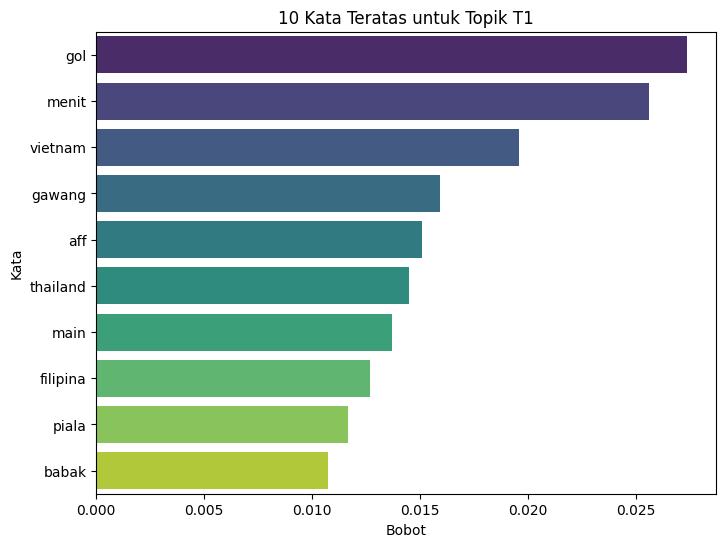

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

top_n = 10
plt.figure(figsize=(8,6))
sns.barplot(
    data=df_kata_topik[df_kata_topik['Topik']=='T1'].head(top_n),
    x='Bobot', y='Kata', palette='viridis'
)
plt.title('10 Kata Teratas untuk Topik T1')
plt.show()


## **Memvisualisasikan distribusi topik dominan di seluruh dokumen**

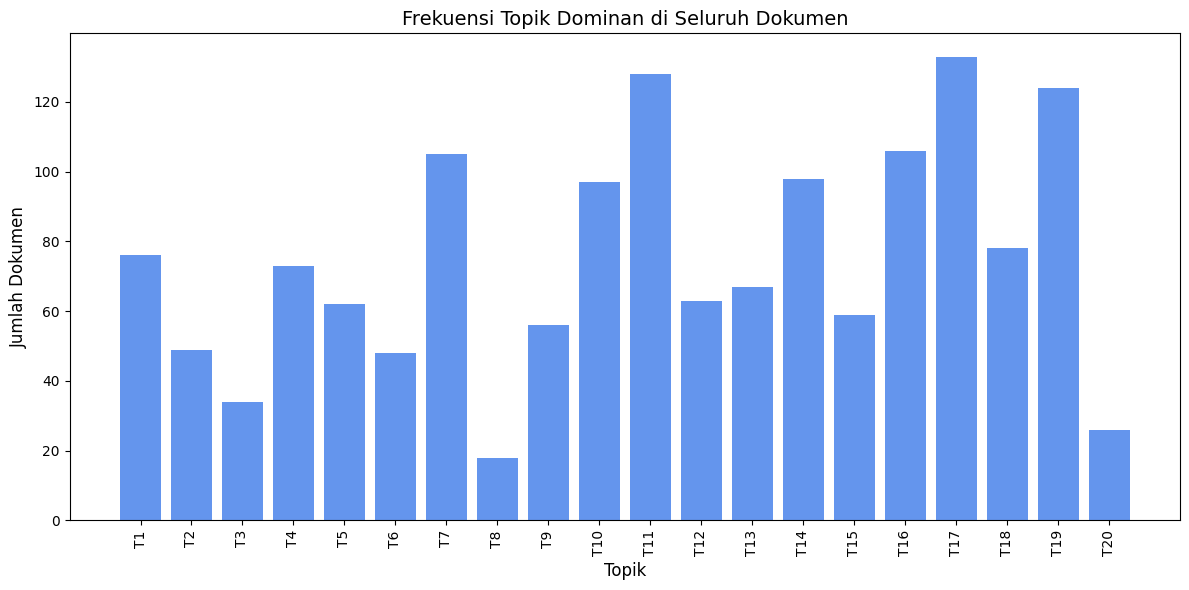

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Ambil topik dominan tiap dokumen
df_topik_only = df_hasil_topik[[f'T{i+1}' for i in range(jumlah_topik)]]
df_topik_only['dominant_topic'] = df_topik_only.idxmax(axis=1)

# 2️⃣ Hitung frekuensi tiap topik dominan
topic_counts = df_topik_only['dominant_topic'].value_counts()

# 3️⃣ Urutkan berdasarkan angka di nama topik
topic_counts = topic_counts.reindex(
    sorted(topic_counts.index, key=lambda x: int(x[1:]))  # ambil angka setelah "T"
)

# 4️⃣ Plot bar chart sederhana
plt.figure(figsize=(12,6))
plt.bar(topic_counts.index, topic_counts.values, color='cornflowerblue')
plt.title("Frekuensi Topik Dominan di Seluruh Dokumen", fontsize=14)
plt.xlabel("Topik", fontsize=12)
plt.ylabel("Jumlah Dokumen", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [65]:
from gensim import corpora
from gensim.models import CoherenceModel
import numpy as np
import pandas as pd
from IPython.display import display

## **Coherence Score per Topik**

In [66]:
vocab = vectorizer.get_feature_names_out()

tokenized_text = [doc.split() for doc in corpus]

id2word = corpora.Dictionary(tokenized_text)
corpus_gensim = [id2word.doc2bow(text) for text in tokenized_text]

topic_word = lda_model.components_
topic_word = topic_word / topic_word.sum(axis=1)[:, np.newaxis]

topics = []
for topic in topic_word:
    top_tokens = [vocab[i] for i in topic.argsort()[:-11:-1]]
    topics.append(top_tokens)

coherence_model_lda = CoherenceModel(
    topics=topics,
    texts=tokenized_text,
    dictionary=id2word,
    coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()

print(f"\n✅ Coherence Score keseluruhan model LDA: {coherence_lda:.4f}")



coherence_per_topic = coherence_model_lda.get_coherence_per_topic()

df_coherence = pd.DataFrame({
    'Topik': [f'T{i+1}' for i in range(len(coherence_per_topic))],
    'Coherence_Score': coherence_per_topic
})

print("\n📊 Coherence Score per Topik:")
display(df_coherence.head(10))  # tampilkan 10 dulu, biar tidak terlalu panjang


✅ Coherence Score keseluruhan model LDA: 0.6136

📊 Coherence Score per Topik:


,Topik,Coherence_Score
0,T1,0.895296
1,T2,0.566139
2,T3,0.518107
3,T4,0.359851
4,T5,0.439384
5,T6,0.397553
6,T7,0.936374
7,T8,0.586095
8,T9,0.601149
9,T10,0.611902


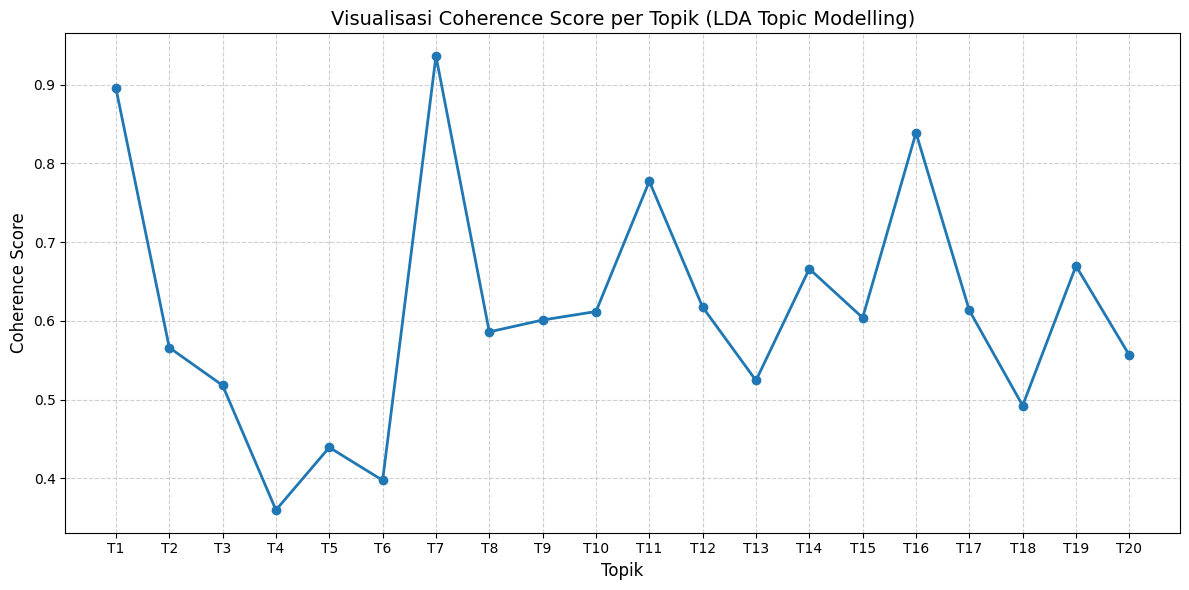

In [67]:
# ============================================
# Tahap: Visualisasi Coherence Score per Topik
# ============================================

import matplotlib.pyplot as plt

# 1️⃣ Pastikan df_coherence sudah ada dari tahap sebelumnya
# Jika belum, df_coherence berisi dua kolom: Topik dan Coherence_Score

plt.figure(figsize=(12, 6))
plt.plot(df_coherence['Topik'], df_coherence['Coherence_Score'], marker='o', linestyle='-', linewidth=2)

# 2️⃣ Tambahkan judul dan label
plt.title('Visualisasi Coherence Score per Topik (LDA Topic Modelling)', fontsize=14)
plt.xlabel('Topik', fontsize=12)
plt.ylabel('Coherence Score', fontsize=12)

# 3️⃣ Tambahkan grid agar mudah dibaca
plt.grid(True, linestyle='--', alpha=0.6)

# 4️⃣ Tampilkan plot
plt.tight_layout()
plt.show()

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:

X = df_hasil_topik[[f'T{i+1}' for i in range(20)]]

# Ambil label kategori berita
y = df_hasil_topik['kategori']

# Cek struktur data
display(X)
display(y)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20
0,0.000150,0.000150,0.000150,0.247797,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.000150,0.476896,0.000150,0.194115,0.078790
1,0.000124,0.000124,0.000124,0.000124,0.000124,0.512559,0.000124,0.000124,0.000124,0.319917,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.000124,0.078277,0.087257
2,0.000175,0.000175,0.108997,0.000175,0.272844,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.000175,0.303605,0.000175,0.000175,0.311757
3,0.000230,0.000230,0.000230,0.000230,0.000230,0.330413,0.000230,0.081240,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.000230,0.199703,0.000230,0.384958,0.000230
4,0.000191,0.000191,0.013424,0.540196,0.000191,0.000191,0.000191,0.000191,0.007435,0.070447,0.000191,0.000191,0.000191,0.000191,0.000191,0.000191,0.197277,0.000191,0.118358,0.050382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.000225,0.154713,0.000225,0.000225,0.641768,0.000225,0.095821,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.000225,0.104094,0.000225,0.000225
1496,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.997293,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142,0.000142
1497,0.040412,0.000177,0.000177,0.000177,0.000177,0.000177,0.713951,0.000177,0.000177,0.105283,0.000177,0.034599,0.000177,0.000177,0.051920,0.000177,0.000177,0.051362,0.000177,0.000177
1498,0.000195,0.184206,0.000195,0.000195,0.723995,0.000195,0.015608,0.000195,0.045571,0.000195,0.027691,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195,0.000195


,kategori
0,Ekonomi
1,Ekonomi
2,Ekonomi
3,Ekonomi
4,Ekonomi
...,...
1495,Internasional
1496,Internasional
1497,Internasional
1498,Internasional


In [70]:
print(y.value_counts())

kategori
Ekonomi          375
Olahraga         375
Nasional         375
Internasional    375
Name: count, dtype: int64


## **Pemodelan Klasifikasi**

In [71]:
# Hapus kelas yang jumlah datanya kurang dari 2
mask = y.isin(y.value_counts()[y.value_counts() > 1].index)
X = X[mask]
y = y[mask]

# Split ulang dengan stratify
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cek hasil proporsi di masing-masing set
print("Distribusi label di TRAIN:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribusi label di TEST:")
print(y_test.value_counts(normalize=True).round(3))

Distribusi label di TRAIN:
kategori
Internasional    0.25
Nasional         0.25
Olahraga         0.25
Ekonomi          0.25
Name: proportion, dtype: float64

Distribusi label di TEST:
kategori
Internasional    0.25
Olahraga         0.25
Nasional         0.25
Ekonomi          0.25
Name: proportion, dtype: float64


### **SVM**

In [72]:
# Inisialisasi model SVM
svm_model = SVC(kernel='linear', random_state=42)

# Latih model
svm_model.fit(X_train, y_train)

# Prediksi
y_pred_svm = svm_model.predict(X_test)

### **MultinomialNB**

In [73]:
# Import library
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inisialisasi model Naive Bayes Multinomial
nb_model = MultinomialNB()

# Latih model
nb_model.fit(X_train, y_train)

# Prediksi
y_pred_nb = nb_model.predict(X_test)


### Evaluasi dan Visualisasi


=== Evaluasi Model: SVM ===
Accuracy : 0.8666666666666667
Precision: 0.8830704902133474
Recall   : 0.8666666666666667

Classification Report:
                precision    recall  f1-score   support

      Ekonomi       0.72      0.95      0.82        75
Internasional       0.91      0.95      0.93        75
     Nasional       0.92      0.60      0.73        75
     Olahraga       0.99      0.97      0.98        75

     accuracy                           0.87       300
    macro avg       0.88      0.87      0.86       300
 weighted avg       0.88      0.87      0.86       300



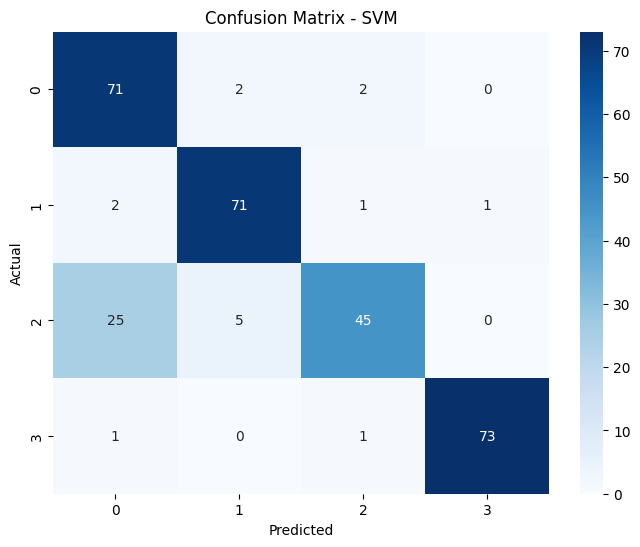


=== Evaluasi Model: Naive Bayes Multinominal ===
Accuracy : 0.87
Precision: 0.8823722818147669
Recall   : 0.87

Classification Report:
                precision    recall  f1-score   support

      Ekonomi       0.73      0.95      0.83        75
Internasional       0.92      0.92      0.92        75
     Nasional       0.90      0.63      0.74        75
     Olahraga       0.97      0.99      0.98        75

     accuracy                           0.87       300
    macro avg       0.88      0.87      0.87       300
 weighted avg       0.88      0.87      0.87       300



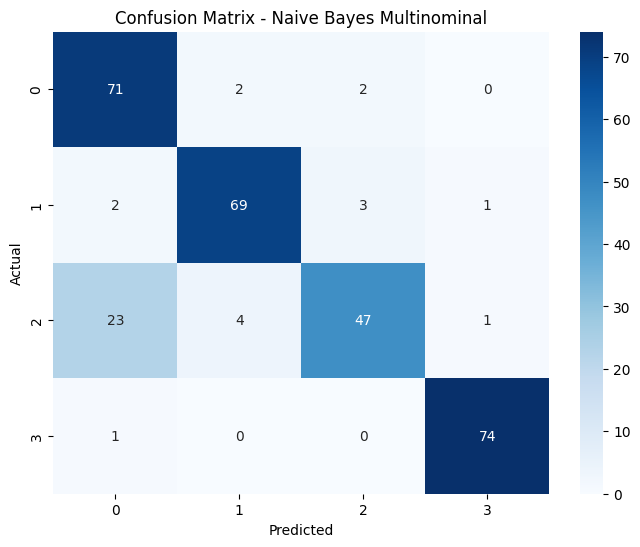

In [74]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluasi SVM
evaluasi_model(y_test, y_pred_svm, "SVM")
# Evaluasi NB
evaluasi_model(y_test, y_pred_nb, "Naive Bayes Multinominal")
